# GRAFIKA KOMPUTEROWA
# Laboratorium 1 *Modele kolorów i ich przekształcanie*

### Joanna Dagil (231008)

# Cel ćwiczenia

Zapoznanie się z różnymi modelami kolorów w obrazach rastrowych. Konwesrsja między tymi modelami poprzez mnożenie przez macierze przekształcenia.


# Zadanie 1 Zamiana obrazu RGB na YUV oraz na YCbCr, oraz transformacja odwrotna.

Załadujmy i wyświetlmy obraz.

Saving obraz.bmp to obraz (3).bmp


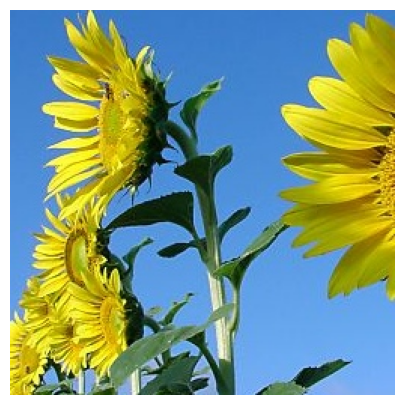

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from google.colab import files
image = files.upload()

# wczytanie obrazu
image = np.asarray(Image.open("obraz.bmp").convert("RGB"), dtype=np.float64)

# wyświetlenie obrazu
def show(image):
  plt.figure(figsize=(5, 5))
  plt.imshow(np.clip(image, 0, 255).astype(np.uint8))
  plt.axis("off")
  plt.show()

show(image)

## Podział na warstwy, ich normalizacja i wyświetlenie

Funkcja normalizująca macierz kanału. Jeśli wartości są ujemne to zmieniamy je na dodatnie. Będzie to przydatne dla formató YUV i YCbCr.

In [20]:
def normalize_channel(channel):
    cmin = channel.min()
    cmax = channel.max()
    if cmax == cmin:
        return np.zeros_like(channel, dtype=np.float64)
    return (channel - cmin) / (cmax - cmin)

Wyświetlenie obrazu RGB w trzech wersjach, po jednej dla każdej macierzy koloru.

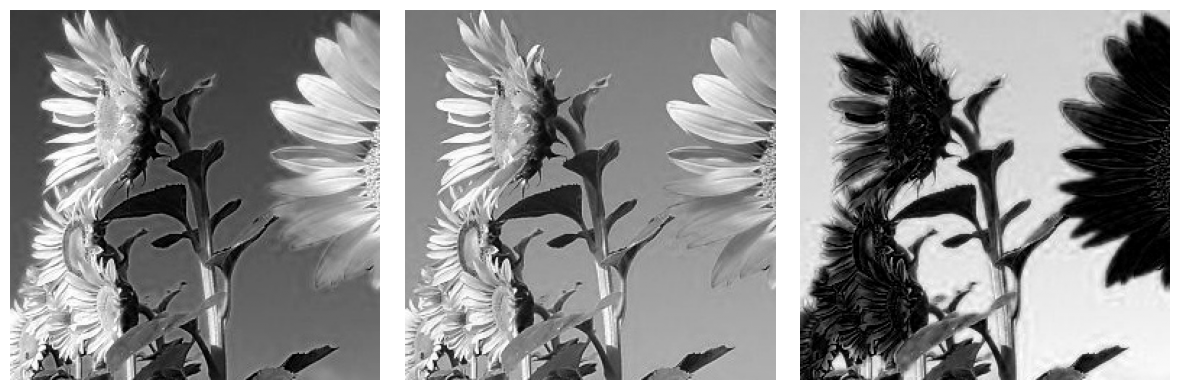

In [21]:
def show_channels(image):
    plt.figure(figsize=(12, 4))
    for i in range(3):
        channel = image[:, :, i]
        channel_to_show = normalize_channel(channel)
        plt.subplot(1, 3, i + 1)
        plt.imshow(channel_to_show, cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_channels(image)

## 1 (a) Przekształcanie obrazu z formatu RGB do formatu YUV.

Funkcja zapisuje wymiary obrazu, spłaszcza go, przemnaża przez macierz przekształcenia i przywraca pierwotne wymiary. Następnie wyświetlamy kanały otrzymanego obrazu.


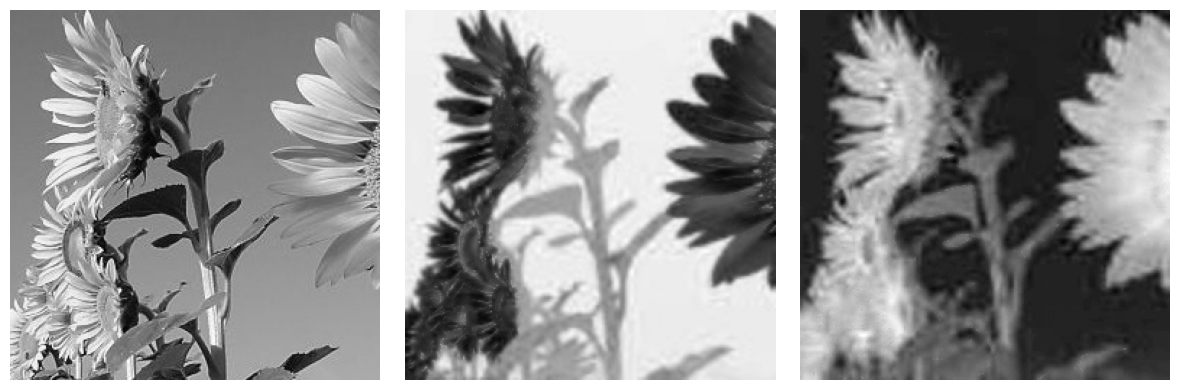

In [22]:
H = np.array([
        [0.2126,   0.7152,   0.0722],
        [-0.09991, -0.33609, 0.436],
        [0.615,   -0.55861, -0.05639]
    ], dtype=np.float64)
def rgb_to_yuv(image, H):
    h, w, c = image.shape
    transformed = H @ image.reshape(-1, 3).T
    return transformed.T.reshape(h, w, 3)
image_yuv = rgb_to_yuv(image, H)
show_channels(image_yuv)

## 1 (b) Przekształcanie obrazu z formatu RGB do formatu YCbCr

Analogicznie jak wyżej.

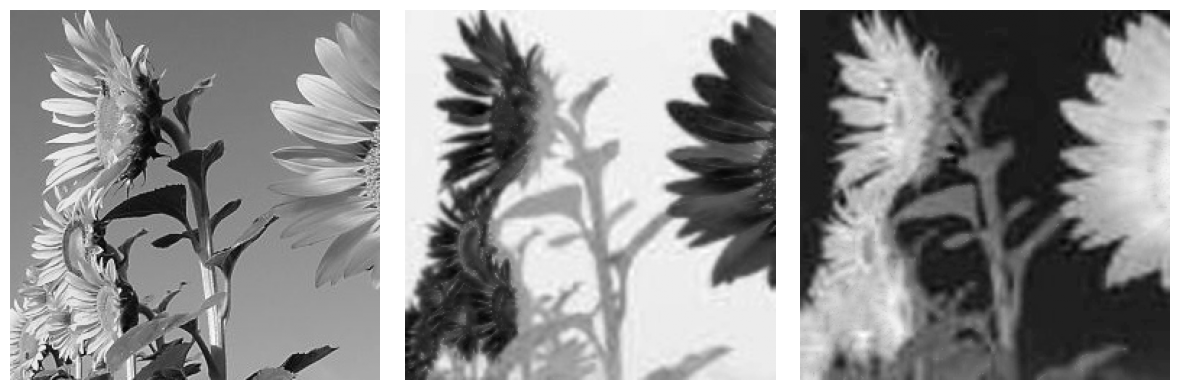

In [23]:
kR=0.299; kG=0.587; kB=0.114
K = np.array([
    [kR, kG, kB],
    [-0.5 * kR / (1 - kB), -0.5 * kG / (1 - kB), 0.5],
    [0.5, -0.5 * kG / (1 - kR), -0.5 * kB / (1 - kR)]
  ], dtype=np.float64)

def rgb_to_ycbcr(image, K):
    h, w, c = image.shape
    transformed = K @ image.reshape(-1, 3).T
    return transformed.T.reshape(h, w, 3)
image_ycbcr = rgb_to_ycbcr(image, K)
show_channels(image_ycbcr)

## Odwrócenie przekształcenia

Funkcja odwraca macierz przekształcenia, a następnie postępuje jak w powyższych zadaniach - przemnaża obraz YUV przez otrzymaną macierz. Wyświetlamy otrzymany obraz i liczymy różnicę między orginalnym, a zmienionym i przywróconym obrazem - błąd jest znikomy.

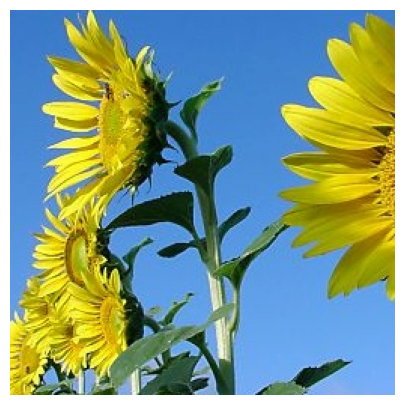

MSE: 6.117156350575284e-28


In [24]:
def inverse_transform_image(image, H):
    H_inv = np.linalg.inv(H)
    h, w, c = image.shape
    transformed = H_inv @ image.reshape(-1, 3).T
    return transformed.T.reshape(h, w, 3)

def mse(a, b):
    return np.mean((a - b) ** 2)

reversed = inverse_transform_image(image_yuv, H)
show(reversed)
print("MSE:", mse(image, reversed))

# Zadanie 2 Zmiana obrazów na monochromatyczne.

## (a) Używając średniej z wartości kanałów R, G i B

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

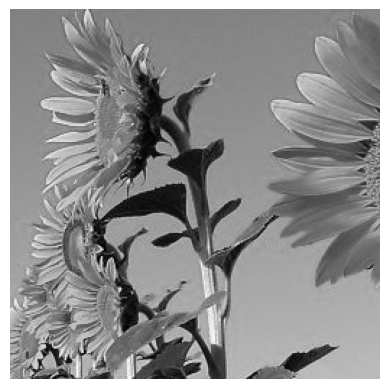

In [25]:
def average_channel(image):
  mono = (image[:, :, 0] + image[:, :, 1] + image[:, :, 2]) / 3
  return mono

RGB_mean = average_channel(image)

plt.imshow(RGB_mean, cmap="gray")
plt.axis("off")

## (b) Używając kanału Y z Zadania 1(a)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

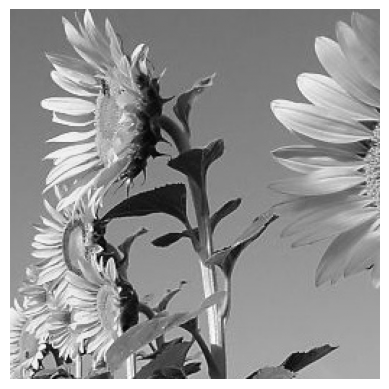

In [26]:
YUV_Y = image_yuv[:, :, 0]
YUV_Y_norm = (YUV_Y - YUV_Y.min()) / (YUV_Y.max() - YUV_Y.min())
plt.imshow(YUV_Y_norm, cmap="gray")
plt.axis("off")

Porównajmy błędem średnio kwadratowym różnice między uśrednionym obrazem RGB i kanałem Y z obrazu YUV.

Aby tego dokonać najpierw normalizujemy uśredniony obraz RGB, gdyż jego wartości są z zakresu 0-255, a YUV z 0-1.

In [27]:
RGB_mean_norm = normalize_channel(RGB_mean)
print("MSE:", mse(RGB_mean_norm, YUV_Y_norm))

MSE: 0.008677641580911893


## (c) Używając kanału Y z Zadania 1(b)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

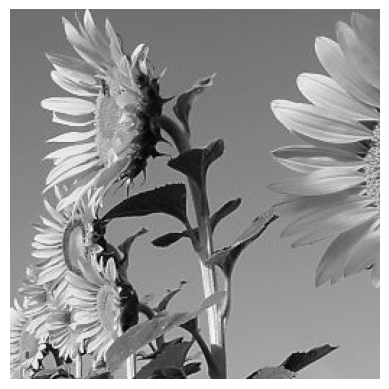

In [28]:
YCbCr_Y = image_ycbcr[:, :, 0]
YCbCr_Y_norm = (YCbCr_Y - YCbCr_Y.min()) / (YCbCr_Y.max() - YCbCr_Y.min())
plt.imshow(YCbCr_Y_norm, cmap="gray")
plt.axis("off")

Porównajmy obrazy uśrednionego RGB i kanałów Y z YUV i YCbCr.

In [29]:
print("MSE:", mse(RGB_mean_norm, YCbCr_Y_norm))
print("MSE:", mse(YUV_Y_norm, YCbCr_Y_norm))

MSE: 0.007235085083421994
MSE: 0.00017220304603432824


Widzmy, że różnica istnieje. Jest zdecydowanie wieksza niż w przypadku zmiany obrazu RGB na YUV i spowrotem, gdy różnica była rzędu wielkości `e-28`

## Zadanie 3 Odzyskanie orginalnego obrazu z monochromatycznych obrazów z zadania 2

W obrazie $RGB\_mean$ dla każdego piksela

$$X_{ij} = (R_{ij} + G_{ij} + B_{ij})/3$$

W obrazie $YUV\_Y$ dla każdego piksela

$$Y_{ij} = 0.2126 \cdot R_{ij} + 0.7152 \cdot G_{ij} + 0.0722 \cdot B_{ij}$$

W obrazie $YCbCr\_Y$ dla każdego piksela

$$Z_{ij} = k_R \cdot R_{ij} + k_G \cdot G_{ij} +k_B \cdot B_{ij}$$

Zatem dla każdego piksela mamy układ trzech równań z trzema niewiadomymi. Przepiszmy to na zapis macierzowy.

$$
\begin{bmatrix}
X \\
Y \\
Z
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{3} & \frac{1}{3} & \frac{1}{3} \\
0.2126 & 0.7152 & 0.0722 \\
k_R & k_G & k_B
\end{bmatrix}
\begin{bmatrix}
R \\
G \\
B
\end{bmatrix}
$$

A więc, żeby odzyskać obraz RGB musimy przemnożyć macież odwrotną do powyższej przez macierz z tych trzech kanałów.

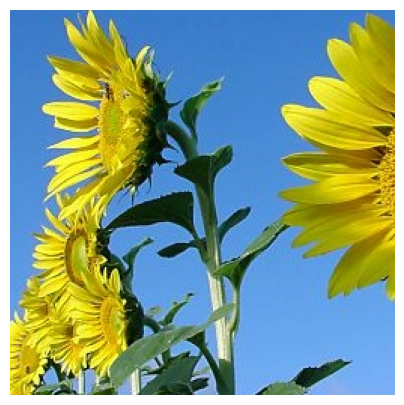

In [30]:
G = np.array([
    [1/3, 1/3, 1/3],
    [0.2126, 0.7152, 0.0722],
    [kR, kG, kB]
], dtype=np.float64)

h, w = image.shape[:2]

XYZ = np.stack([RGB_mean, YUV_Y, YCbCr_Y], axis=2)

RGB_from_mono = (
    np.linalg.inv(G) @ XYZ.reshape(-1,3).T
    ).T.reshape(h, w, 3)

show(RGB_from_mono)


## Zadanie 4 Zmiana RGB na HSV i odwrotnie

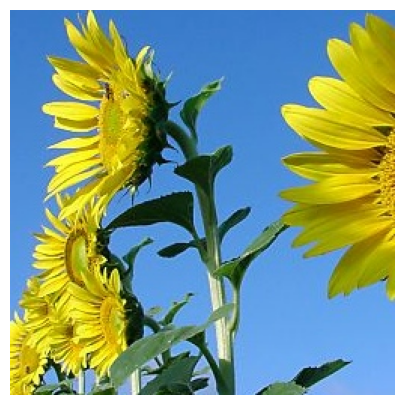

In [31]:
def rgb_to_hsv(rgb):

  rgb = rgb / 255.0

  r = rgb[..., 0]
  g = rgb[..., 1]
  b = rgb[..., 2]

  cmax = np.max(rgb, axis=-1)
  cmin = np.min(rgb, axis=-1)
  delta = cmax - cmin

  h = np.zeros_like(cmax)
  s = np.zeros_like(cmax)
  v = cmax

  nonzero = delta > 0

  mask_r = nonzero & (cmax == r)
  mask_g = nonzero & (cmax == g)
  mask_b = nonzero & (cmax == b)

  h[mask_r] = ((g[mask_r] - b[mask_r]) / delta[mask_r]) % 6
  h[mask_g] = ((b[mask_g] - r[mask_g]) / delta[mask_g]) + 2
  h[mask_b] = ((r[mask_b] - g[mask_b]) / delta[mask_b]) + 4

  h = h / 6.0

  nonzero_cmax = cmax > 0
  s[nonzero_cmax] = delta[nonzero_cmax] / cmax[nonzero_cmax]

  hsv = np.stack([h, s, v], axis=-1)
  return hsv

def hsv_to_rgb(hsv):
  h = hsv[..., 0] * 6.0
  s = hsv[..., 1]
  v = hsv[..., 2]

  c = v * s
  x = c * (1 - np.abs((h % 2) - 1))
  m = v - c

  r1 = np.zeros_like(h)
  g1 = np.zeros_like(h)
  b1 = np.zeros_like(h)

  mask0 = (0 <= h) & (h < 1)
  mask1 = (1 <= h) & (h < 2)
  mask2 = (2 <= h) & (h < 3)
  mask3 = (3 <= h) & (h < 4)
  mask4 = (4 <= h) & (h < 5)
  mask5 = (5 <= h) & (h <= 6)

  r1[mask0], g1[mask0], b1[mask0] = c[mask0], x[mask0], 0
  r1[mask1], g1[mask1], b1[mask1] = x[mask1], c[mask1], 0
  r1[mask2], g1[mask2], b1[mask2] = 0, c[mask2], x[mask2]
  r1[mask3], g1[mask3], b1[mask3] = 0, x[mask3], c[mask3]
  r1[mask4], g1[mask4], b1[mask4] = x[mask4], 0, c[mask4]
  r1[mask5], g1[mask5], b1[mask5] = c[mask5], 0, x[mask5]

  r = r1 + m
  g = g1 + m
  b = b1 + m

  rgb = np.stack([r, g, b], axis=-1)
  return np.clip(rgb, 0, 1) * 255.0

changed = hsv_to_rgb(rgb_to_hsv(image))
show(changed)

Porównajmy obraz orginalny i przekształcony na hsv i spowrotem.

Wynik jest znikomy - a więc obrazy są jednakowe.

In [32]:
print("MSE:", mse(image, changed))

MSE: 3.1487321637864265e-28


# Zadanie 5

Zamiana różnych odcieni białego z modelu CIELAB na RGB.

Zamiast matlabowej funkcji *xyz2rgb* wykorzystam mnożenie przez macierz i następnie ucięcie do wartości [0,1], gdyż obrazy RGB NIE ODDAJĄ w pełni kolorów z XYZ.

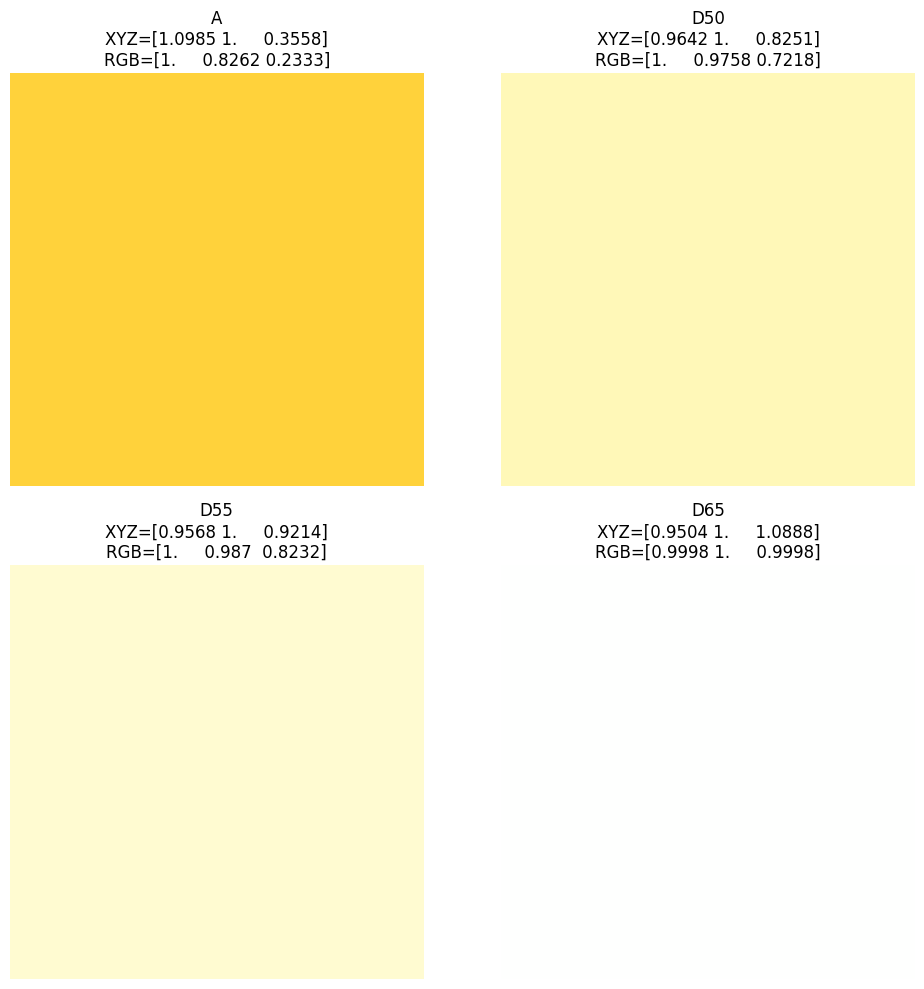

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# zamiast matlabowej funkcji xyz2rgb
M_XYZ_to_RGB = np.array([
    [ 3.2406, -1.5372, -0.4986],
    [-0.9689,  1.8758,  0.0415],
    [ 0.0557, -0.2040,  1.0570]
], dtype=np.float64)

# standardy bieli z zadania
white_points = {
    "A":   np.array([1.0985, 1.0000, 0.3558]),
    "D50": np.array([0.9642, 1.0000, 0.8251]),
    "D55": np.array([0.9568, 1.0000, 0.9214]),
    "D65": np.array([0.9504, 1.0000, 1.0888]),
}

def xyz_to_rgb(xyz):
    rgb = M_XYZ_to_RGB @ xyz
    return np.clip(rgb, 0, 1)

def make_white_image(rgb, size=256):
    img = np.ones((size, size, 3), dtype=np.float64)
    img[..., 0] *= rgb[0]
    img[..., 1] *= rgb[1]
    img[..., 2] *= rgb[2]
    return img

# tworzenie obrazów
images = {}
for name, xyz in white_points.items():
    rgb = xyz_to_rgb(xyz)
    images[name] = (xyz, rgb, make_white_image(rgb, 256))

# wyświetlenie
plt.figure(figsize=(10, 10))

for i, (name, (xyz, rgb, img)) in enumerate(images.items(), start=1):
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(f"{name}\nXYZ={xyz.round(4)}\nRGB={rgb.round(4)}")
    plt.axis("off")

plt.tight_layout()
plt.show()